In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv("Kolkata House Price Dataset.csv")
data.head(10)

,Id,Apartment,Society,Location,Price,Price/sqft,SqftArea,Construction_Status,Year's Old,bathrooms,type of property
0,0,2 BHK Apartment,NaN,Baruipur,32 L,"3,265 / sq ft",980,Ready to move,NaN,2 Bathrooms,Resale
1,1,2 BHK Apartment,NaN,Garia,36 L,"4,645 / sq ft",775,Ready to move,NaN,2 Bathrooms,Resale
2,2,2 BHK Independent Floor,NaN,Baranagar,24 L,"3,243 / sq ft",740,Ready to move,NaN,1 Bathrooms,Resale
3,3,1 BHK Apartment,NaN,Garia,30 L,"5,859 / sq ft",512,Ready to move,NaN,1 Bathrooms,Resale
4,4,2 BHK Apartment,NaN,Dhakuria,1.14 Cr,"10,654 / sq ft",1070,Ready to move,NaN,2 Bathrooms,Resale
5,5,3 BHK Apartment,Rajwada Emeralds,Narendrapur,68 L,"5,151 / sq ft",1320,Ready to move,4 - 5 years old,2 Bathrooms,Resale
6,6,3 BHK Apartment,NaN,Bramhapur,35 L,"2,536 / sq ft",1380,Ready to move,6 - 7 years old,2 Bathrooms,Resale
7,7,3 BHK Independent House,NaN,south dum dum,85 L,"4,250 / sq ft",2000,Ready to move,7 - 8 years old,2 Bathrooms,Resale
8,8,2 BHK Apartment,NaN,Uttarpara Kotrung,20 L,"2,702 / sq ft",740,Ready to move,NaN,1 Bathrooms,Resale
9,9,2 BHK Apartment,NaN,New Town,35 L,"4,046 / sq ft",865,Ready to move,NaN,2 Bathrooms,Resale


In [5]:
data.isnull().sum()

Id                       0
Apartment                0
Society                266
Location                 0
Price                    0
Price/sqft               0
SqftArea                 0
Construction_Status      0
Year's Old             222
bathrooms               30
type of property        22
dtype: int64

**AS there are lot of missing values in 'Year's Old' and 'Society' column, we can just drop them**

**Also we don't need 'Id' column in our analysis**

In [6]:
data.drop(columns = ['Id', 'Society', "Year's Old"], inplace = True)

In [7]:
data.head()

,Apartment,Location,Price,Price/sqft,SqftArea,Construction_Status,bathrooms,type of property
0,2 BHK Apartment,Baruipur,32 L,"3,265 / sq ft",980,Ready to move,2 Bathrooms,Resale
1,2 BHK Apartment,Garia,36 L,"4,645 / sq ft",775,Ready to move,2 Bathrooms,Resale
2,2 BHK Independent Floor,Baranagar,24 L,"3,243 / sq ft",740,Ready to move,1 Bathrooms,Resale
3,1 BHK Apartment,Garia,30 L,"5,859 / sq ft",512,Ready to move,1 Bathrooms,Resale
4,2 BHK Apartment,Dhakuria,1.14 Cr,"10,654 / sq ft",1070,Ready to move,2 Bathrooms,Resale


In [8]:
data.isnull().sum()

Apartment               0
Location                0
Price                   0
Price/sqft              0
SqftArea                0
Construction_Status     0
bathrooms              30
type of property       22
dtype: int64

In [9]:
data.shape

(340, 8)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Apartment            340 non-null    object
 1   Location             340 non-null    object
 2   Price                340 non-null    object
 3   Price/sqft           340 non-null    object
 4   SqftArea             340 non-null    int64 
 5   Construction_Status  340 non-null    object
 6   bathrooms            310 non-null    object
 7   type of property     318 non-null    object
dtypes: int64(1), object(7)
memory usage: 21.4+ KB


In [11]:
data['Apartment'].value_counts()

Apartment
2 BHK Apartment            137
3 BHK Apartment             99
Residential Plot            22
4 BHK Independent House     14
7 BHK Villa                 13
3 BHK Independent House      9
1 BHK Apartment              9
2 BHK Independent House      8
2 BHK Independent Floor      7
6 BHK Independent House      7
3 BHK Independent Floor      3
5 BHK Independent House      2
4 BHK Apartment              2
1 BHK Independent Floor      2
1 BHK Independent House      2
1 RK Studio Apartment        1
4 BHK Villa                  1
5 BHK Villa                  1
3 BHK Villa                  1
Name: count, dtype: int64

In [12]:
# Let's remove the row with Apartment = '1 RK Studio Apartment' and 'Residential Plot'
data = data[data['Apartment'] != '1 RK Studio Apartment']
data = data[data['Apartment'] != 'Residential Plot']

In [13]:
data.isnull().sum()

Apartment              0
Location               0
Price                  0
Price/sqft             0
SqftArea               0
Construction_Status    0
bathrooms              8
type of property       0
dtype: int64

**Handling Missing Values**

In [14]:
data.dropna(inplace = True)

In [15]:
data.isnull().sum().sum()

np.int64(0)

**Datatype Correction**

1. Apartment Column

In [16]:
data['Apartment'].value_counts()

Apartment
2 BHK Apartment            132
3 BHK Apartment             97
4 BHK Independent House     14
7 BHK Villa                 13
3 BHK Independent House      9
2 BHK Independent House      8
1 BHK Apartment              8
2 BHK Independent Floor      7
6 BHK Independent House      7
3 BHK Independent Floor      3
4 BHK Apartment              2
1 BHK Independent Floor      2
1 BHK Independent House      2
5 BHK Independent House      2
4 BHK Villa                  1
5 BHK Villa                  1
3 BHK Villa                  1
Name: count, dtype: int64

In [17]:
# Extracting the number of bedrooms (BHK)
data['BHK'] = data['Apartment'].str.extract(r'(\d+)')
# Changing Datatype
data['BHK'] = data['BHK'].astype(int)

In [18]:
data['BHK']

0      2
1      2
2      2
3      1
4      2
      ..
335    3
336    3
337    3
338    2
339    3
Name: BHK, Length: 309, dtype: int64

In [19]:
data.head()

,Apartment,Location,Price,Price/sqft,SqftArea,Construction_Status,bathrooms,type of property,BHK
0,2 BHK Apartment,Baruipur,32 L,"3,265 / sq ft",980,Ready to move,2 Bathrooms,Resale,2
1,2 BHK Apartment,Garia,36 L,"4,645 / sq ft",775,Ready to move,2 Bathrooms,Resale,2
2,2 BHK Independent Floor,Baranagar,24 L,"3,243 / sq ft",740,Ready to move,1 Bathrooms,Resale,2
3,1 BHK Apartment,Garia,30 L,"5,859 / sq ft",512,Ready to move,1 Bathrooms,Resale,1
4,2 BHK Apartment,Dhakuria,1.14 Cr,"10,654 / sq ft",1070,Ready to move,2 Bathrooms,Resale,2


In [20]:
data.drop(columns = 'Apartment', inplace = True)

In [21]:
data.head()

,Location,Price,Price/sqft,SqftArea,Construction_Status,bathrooms,type of property,BHK
0,Baruipur,32 L,"3,265 / sq ft",980,Ready to move,2 Bathrooms,Resale,2
1,Garia,36 L,"4,645 / sq ft",775,Ready to move,2 Bathrooms,Resale,2
2,Baranagar,24 L,"3,243 / sq ft",740,Ready to move,1 Bathrooms,Resale,2
3,Garia,30 L,"5,859 / sq ft",512,Ready to move,1 Bathrooms,Resale,1
4,Dhakuria,1.14 Cr,"10,654 / sq ft",1070,Ready to move,2 Bathrooms,Resale,2


2. Price Column

In [22]:
data['Price']

0          32 L
1          36 L
2          24 L
3          30 L
4       1.14 Cr
         ...   
335        37 L
336        64 L
337        60 L
338        37 L
339     1.75 Cr
Name: Price, Length: 309, dtype: object

In [23]:
def price_to_numeric(price):
    if 'L' in price:
        # Convert 'L' (Lakh) values
        return float(price.replace('L', '').strip()) * 1_00_000
    else:
        # Convert 'Cr' (Crore) values
        return float(price.replace('Cr', '').strip()) * 1_00_00_000

In [24]:
data['Price'] = data['Price'].apply(price_to_numeric)

In [25]:
data['Price']

0       3200000.0
1       3600000.0
2       2400000.0
3       3000000.0
4      11400000.0
          ...    
335     3700000.0
336     6400000.0
337     6000000.0
338     3700000.0
339    17500000.0
Name: Price, Length: 309, dtype: float64

3. Price/sqft Column

In [26]:
data['Price/sqft'].head()

0     3,265 / sq ft
1     4,645 / sq ft
2     3,243 / sq ft
3     5,859 / sq ft
4    10,654 / sq ft
Name: Price/sqft, dtype: object

In [27]:
# Removing Non-numeric Characters
data['Price/sqft'] = data['Price/sqft'].str.replace(',', '')
data['Price/sqft'] = data['Price/sqft'].str.replace(' / sq ft', '')
# Changing DataType
data['Price/sqft'] = data['Price/sqft'].astype(int)

In [28]:
data['Price/sqft']

0       3265
1       4645
2       3243
3       5859
4      10654
       ...  
335     4039
336     5079
337     5084
338     5692
339     9971
Name: Price/sqft, Length: 309, dtype: int64

4. bathrooms Column

In [29]:
data['bathrooms'].value_counts()

bathrooms
2 Bathrooms    185
3 Bathrooms     58
5 Bathrooms     29
1 Bathrooms     27
6 Bathrooms      7
4 Bathrooms      3
Name: count, dtype: int64

In [30]:
data['bathrooms'] = data['bathrooms'].str.replace(' Bathrooms', '')
data['bathrooms'] = data['bathrooms'].astype(int)

In [31]:
data['bathrooms']

0      2
1      2
2      1
3      1
4      2
      ..
335    2
336    3
337    2
338    1
339    3
Name: bathrooms, Length: 309, dtype: int64

**Handling Duplicates**

In [32]:
data.duplicated().sum()

np.int64(147)

In [33]:
data.drop_duplicates(keep = 'last', inplace = True)
data.duplicated().sum()

np.int64(0)

**Final Data**

In [34]:
data

,Location,Price,Price/sqft,SqftArea,Construction_Status,bathrooms,type of property,BHK
0,Baruipur,3200000.0,3265,980,Ready to move,2,Resale,2
1,Garia,3600000.0,4645,775,Ready to move,2,Resale,2
2,Baranagar,2400000.0,3243,740,Ready to move,1,Resale,2
3,Garia,3000000.0,5859,512,Ready to move,1,Resale,1
4,Dhakuria,11400000.0,10654,1070,Ready to move,2,Resale,2
...,...,...,...,...,...,...,...,...
335,Barasat,3700000.0,4039,916,Ready to move,2,Resale,3
336,Nayabad,6400000.0,5079,1260,Ready to move,3,Resale,3
337,New Town,6000000.0,5084,1180,Ready to move,2,Resale,3
338,Patuli,3700000.0,5692,650,Ready to move,1,Resale,2


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162 entries, 0 to 339
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Location             162 non-null    object 
 1   Price                162 non-null    float64
 2   Price/sqft           162 non-null    int64  
 3   SqftArea             162 non-null    int64  
 4   Construction_Status  162 non-null    object 
 5   bathrooms            162 non-null    int64  
 6   type of property     162 non-null    object 
 7   BHK                  162 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 11.4+ KB


In [36]:
data['type of property'].value_counts()

type of property
Resale     157
New          5
Name: count, dtype: int64

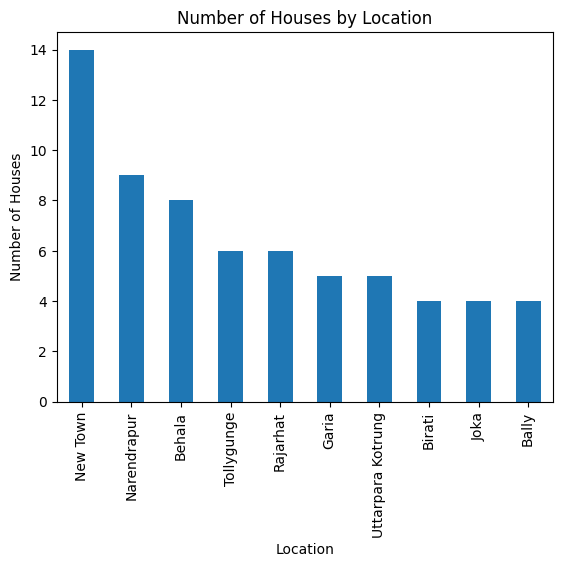

In [37]:
data['Location'].value_counts().sort_values(ascending = False).head(10).plot(kind = 'bar')
plt.title('Number of Houses by Location')
plt.ylabel('Number of Houses')
plt.xlabel('Location')
plt.show()

In [38]:
data['Location'].value_counts()

Location
New Town       14
Narendrapur     9
Behala          8
Tollygunge      6
Rajarhat        6
               ..
Alipore         1
Ichlabad        1
Dhapa           1
Konnagar        1
Mominpore       1
Name: count, Length: 67, dtype: int64

In [39]:
data.groupby('Location')['Price'].mean().sort_values(ascending = False).astype(int) 

Location
Sankrail            37000000
New Garia           29000000
Gariahat            25000000
Mominpore           17500000
Budge Budge         16500000
                      ...   
Barasat              2650000
Kanchrapara Loco     2550000
Amtala               2529000
Topsia               1600000
Garden Reach         1555000
Name: Price, Length: 67, dtype: int64

In [40]:
data.head()

,Location,Price,Price/sqft,SqftArea,Construction_Status,bathrooms,type of property,BHK
0,Baruipur,3200000.0,3265,980,Ready to move,2,Resale,2
1,Garia,3600000.0,4645,775,Ready to move,2,Resale,2
2,Baranagar,2400000.0,3243,740,Ready to move,1,Resale,2
3,Garia,3000000.0,5859,512,Ready to move,1,Resale,1
4,Dhakuria,11400000.0,10654,1070,Ready to move,2,Resale,2


In [41]:
data['Construction_Status'].value_counts()

Construction_Status
Ready to move    162
Name: count, dtype: int64

In [42]:
data.drop('Construction_Status', axis = 1, inplace = True)

In [43]:
data.groupby('type of property')['Price'].mean().sort_values(ascending = False).astype(int) 

type of property
Resale     6329382
New        4087400
Name: Price, dtype: int64

In [44]:
data.select_dtypes(include = 'number').corr()

,Price,Price/sqft,SqftArea,bathrooms,BHK
Price,1.000000,0.616207,0.848763,0.675369,0.655046
Price/sqft,0.616207,1.000000,0.226580,0.221375,0.177422
SqftArea,0.848763,0.226580,1.000000,0.712875,0.728686
bathrooms,0.675369,0.221375,0.712875,1.000000,0.838282
BHK,0.655046,0.177422,0.728686,0.838282,1.000000


In [45]:
X = data[['BHK', 'bathrooms', 'SqftArea','Price/sqft']]
y = data['Price']

In [46]:
np.random.seed(30)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7)

In [47]:
X_train

,BHK,bathrooms,SqftArea,Price/sqft
220,1,1,400,4000
288,3,2,960,3854
295,2,2,890,3483
233,4,4,6000,6166
313,2,2,980,7653
...,...,...,...,...
305,2,2,804,4726
327,3,2,1260,5952
315,2,2,760,4210
176,3,2,1414,7425


In [48]:
X_test.shape

(49, 4)

In [49]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [50]:
X_train = scaler.fit_transform(X_train)

In [51]:
X_train

array([[-1.82385722e+00, -1.39327882e+00, -1.10774549e+00,
        -4.23291582e-01],
       [ 6.44356742e-01, -2.35628035e-01, -2.28794057e-01,
        -4.71111739e-01],
       [-5.89750238e-01, -2.35628035e-01, -3.38662986e-01,
        -5.92627345e-01],
       [ 1.87846372e+00,  2.07967353e+00,  7.68176880e+00,
         2.86149932e-01],
       [-5.89750238e-01, -2.35628035e-01, -1.97402935e-01,
         7.73194961e-01],
       [-5.89750238e-01, -2.35628035e-01, -4.42253690e-01,
        -1.43576414e-01],
       [ 6.44356742e-01,  9.22022746e-01, -2.44489618e-01,
         8.52130974e-01],
       [-5.89750238e-01, -2.35628035e-01, -2.60185180e-01,
         2.17695050e-01],
       [ 6.44356742e-01,  9.22022746e-01,  5.37260450e-02,
        -3.54509164e-01],
       [ 6.44356742e-01,  9.22022746e-01, -2.44489618e-01,
         1.36930925e+00],
       [ 6.44356742e-01,  9.22022746e-01,  4.90173766e-02,
        -6.26751888e-02],
       [-5.89750238e-01, -2.35628035e-01, -4.39114577e-01,
      

In [52]:
import joblib
joblib.dump(scaler, 'Scaler.pkl')

['Scaler.pkl']

In [53]:
X_test = scaler.fit_transform(X_test)

In [54]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators = 300, random_state = 40)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=40)

In [55]:
y_pred =rf.predict(X_test)

In [56]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error:', mae)

Mean Absolute Error: 705075.3741496598


In [57]:
data['Price'].describe().astype(int)

count         162
mean      6260185
std       5920853
min       1200000
25%       3131000
50%       4000000
75%       6975000
max      37000000
Name: Price, dtype: int64

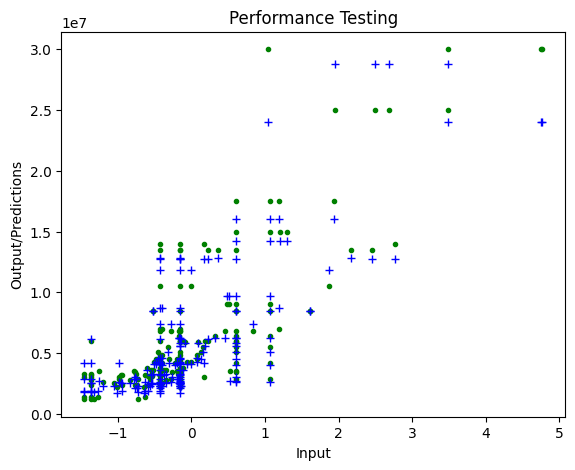

In [58]:
plt.figure(figsize = (6.5,5))
plt.plot(X_test, y_test, '.', color = 'green')
plt.plot(X_test, y_pred, '+', color = 'blue')
plt.title('Performance Testing')
plt.xlabel('Input')
plt.ylabel('Output/Predictions')
plt.show()

In [59]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.2f}")

R² Score: 0.96


In [60]:
joblib.dump(rf, 'model.pkl')

['model.pkl']

In [61]:
from sklearn.metrics import r2_score